# EP1 — Optimización, regularización y evaluación final

Este notebook integra la evidencia de Cesar para E6–F1. Es **de solo lectura**: carga las tablas y figuras versionadas, no reentrena modelos y no consulta el conjunto oficial de test. La evaluación de test ya se ejecutó una única vez después de congelar F0.

In [1]:
from pathlib import Path

from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'results' / 'tables').is_dir():
    raise FileNotFoundError('Ejecute desde la raíz del repositorio o desde notebooks/.')

TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'

def show_table(filename):
    display(Markdown((TABLES / filename).read_text(encoding='utf-8')))

def show_figure(filename, width=760):
    display(Image(filename=str(FIGURES / filename), width=width))

print(f'Raíz del repositorio: {ROOT}')

Raíz del repositorio: C:\Users\cesar\OneDrive\Desktop\DuocUC\3erYear\deepLearning\ep1-deep-learning-fashion-mnist


## E6 y E6b — optimizadores

E6 comparó SGD, RMSProp y Adam con el mismo learning rate (`0,1`) para aislar el optimizador. Como Adam y RMSProp no convergieron adecuadamente con esa escala, E6b ajustó **solo** su learning rate a `0,001`. SGD conservó el mejor compromiso y se usó como control de las etapas siguientes.

# E6 — comparación inicial controlada de optimizadores

Todos los experimentos usan la misma partición estratificada, seed 42, arquitectura `[256, 128]`, ReLU, salida Softmax, categorical crossentropy, `learning_rate=0,1`, batch 128, 20 épocas y ninguna regularización. La única variable modificada es el optimizador. El test oficial no fue evaluado ni se generaron predicciones sobre él.

| ID | Optimizador | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss | Duración CPU |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| E6_optimizer_sgd | **SGD** | **0,8952** | **0,8954** | **0,8952 (20)** | **0,2975 (20)** | 0,0287 | 0,0851 | 156,48 s |
| E6_optimizer_rmsprop | RMSProp | 0,1985 | 0,0684 | 0,2010 (1) | 1,7061 (18) | -0,0001 | -0,0065 | **152,47 s** |
| E6_optimizer_adam | Adam | 0,4722 | 0,4166 | 0,5045 (7) | 1,1918 (4) | 0,0006 | -0,0054 | 152,53 s |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. Las duraciones corresponden a una corrida CPU local y no son comparables con GPU o Colab.

## Lectura y decisión provisional

Con el learning rate común `0,1`, SGD conservó la convergencia esperada. Adam y RMSProp obtuvieron resultados marcadamente inferiores bajo las mismas condiciones. Esto establece el efecto de cambiar exclusivamente el optimizador con un presupuesto compartido, pero **no** permite concluir que Adam o RMSProp sean inferiores en general: ambos pueden requerir otra escala de learning rate.

Se abre E6b como etapa separada: para cada optimizador adaptativo se ajustará el learning rate manteniendo fijos arquitectura, funciones, batch, épocas, seed y regularización. No se selecciona todavía un optimizador final ni se consulta test.

## Evidencia

- `configs/E6_optimizer_sgd.json`
- `configs/E6_optimizer_rmsprop.json`
- `configs/E6_optimizer_adam.json`
- `results/figures/E6_optimizer_validation_accuracy.png`
- `results/figures/E6_optimizer_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E6_optimizer_*`.


# E6b — retuning separado de learning rate por optimizador

E6 mostró que Adam y RMSProp quedaron limitados con el learning rate común `0,1`. E6b mantiene fijo cada optimizador y cambia únicamente su learning rate a `0,001`; arquitectura `[256, 128]`, ReLU, Softmax, categorical crossentropy, batch 128, 20 épocas, seed 42 y ausencia de regularización permanecen constantes. El test oficial no fue evaluado ni se generaron predicciones sobre él.

| ID | Optimizador | Learning rate | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| E6_optimizer_sgd | **SGD** | 0,1 | **0,8952** | **0,8954** | **0,8952 (20)** | **0,2975 (20)** | **0,0287** | **0,0851** |
| E6b_adam_lr_0_001 | Adam | 0,001 | 0,8912 | 0,8916 | 0,8912 (17) | 0,3043 (12) | 0,0527 | 0,1941 |
| E6b_rmsprop_lr_0_001 | RMSProp | 0,001 | 0,8933 | 0,8929 | 0,8933 (16) | 0,3137 (8) | 0,0476 | 0,2165 |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`.

## Decisión provisional

Se mantiene SGD con `learning_rate=0,1` como control provisional para E7. RMSProp recuperó una accuracy cercana, pero quedó 0,18 puntos porcentuales por debajo de SGD, con F1 Macro menor, mayor validation loss y gaps finales de accuracy/loss más altos. Adam también recuperó el aprendizaje, pero quedó por debajo de ambos controles y presentó los gaps más altos.

La diferencia entre SGD y RMSProp es pequeña en accuracy; antes del congelamiento F0 deben repetirse las candidatas relevantes con seeds adicionales si esa diferencia sigue siendo importante para la elección final. Esta decisión solo selecciona un control de continuación para regularización; no congela el modelo ni consulta test.

## Evidencia

- `configs/E6b_adam_lr_0_001.json`
- `configs/E6b_rmsprop_lr_0_001.json`
- `results/figures/E6b_retuned_optimizer_validation_accuracy.png`
- `results/figures/E6b_retuned_optimizer_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E6b_*`.


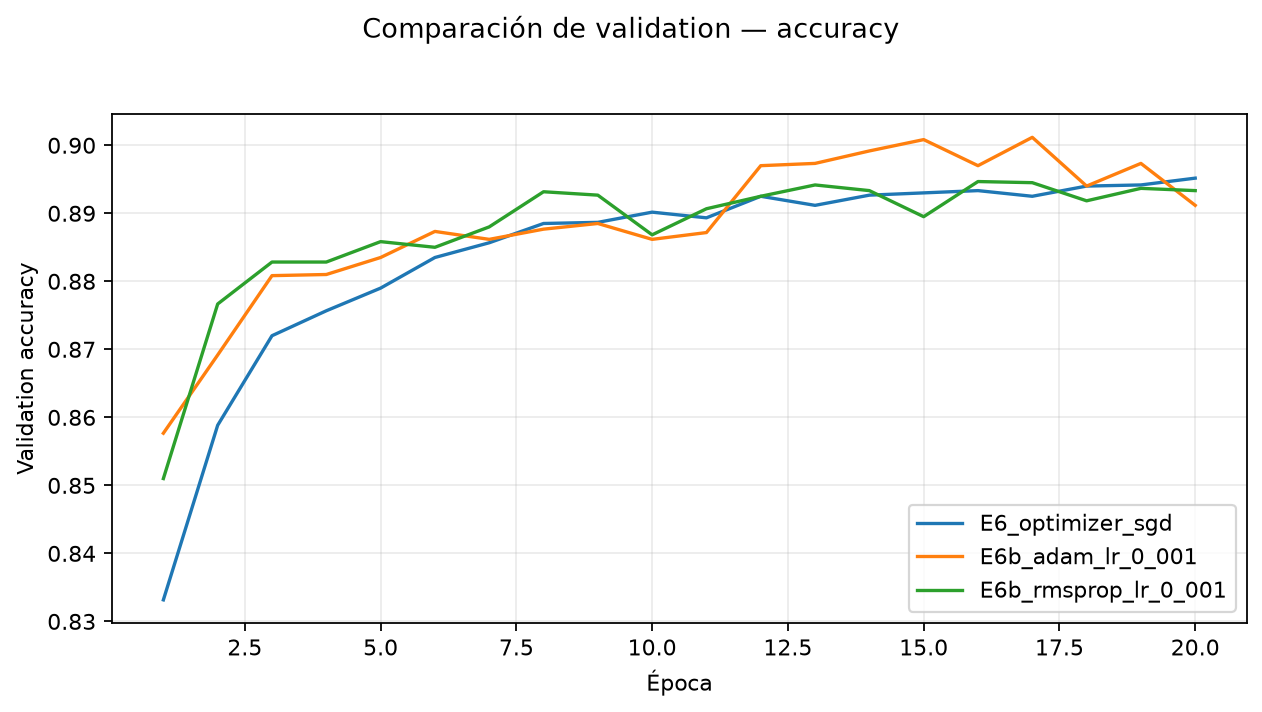

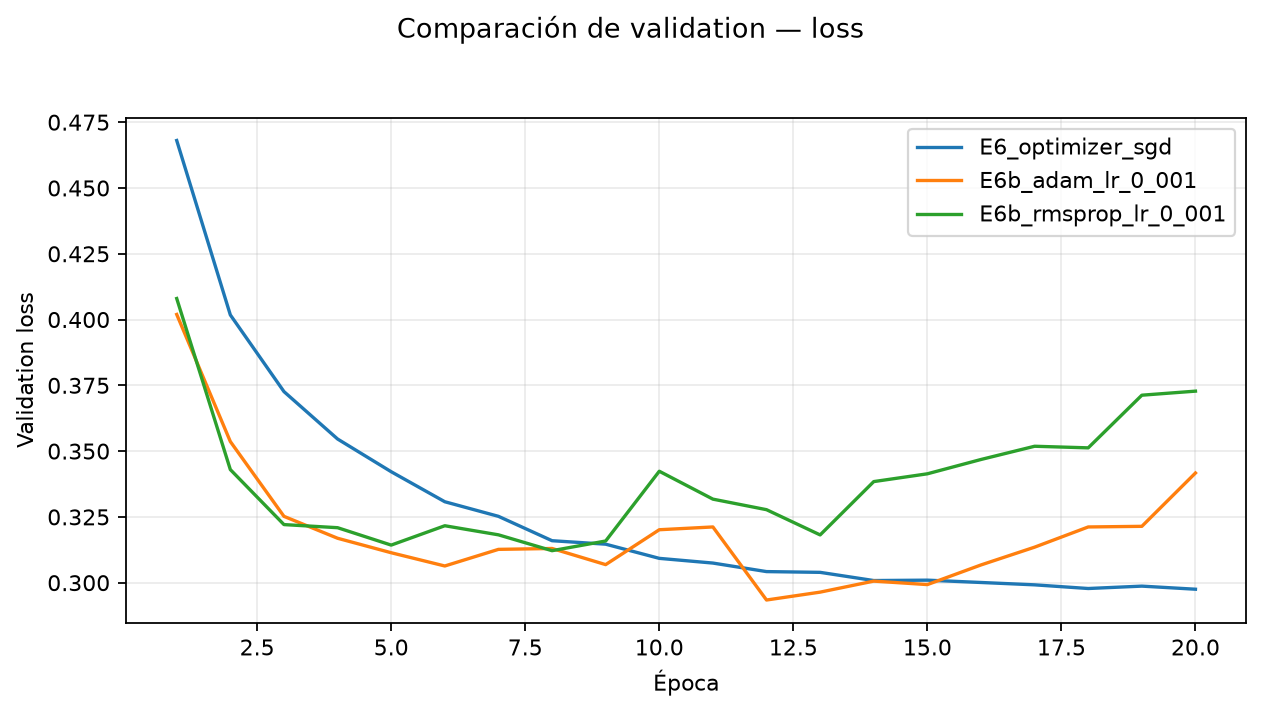

In [2]:
show_table('E6_optimizer_initial_comparison.md')
show_table('E6b_retuned_optimizer_comparison.md')
show_figure('E6b_retuned_optimizer_validation_accuracy.png')
show_figure('E6b_retuned_optimizer_validation_loss.png')

## E7–E9 — regularización

Cada comparación modifica una sola técnica respecto de su control. Dropout `0,2` mejoró la accuracy, F1 Macro y los gaps. En este régimen, Batch Normalization y L2 no mejoraron el control; sus resultados negativos se conservan como evidencia contextual, no como una conclusión general sobre las técnicas.

# E7 — comparación controlada de Dropout

Se parte del control provisional SGD con `learning_rate=0,1`, arquitectura `[256, 128]`, ReLU, Softmax, categorical crossentropy, batch 128, 20 épocas y seed 42. La única variable modificada es Dropout: se aplica después de cada capa oculta cuando está activo. Batch Normalization y L2 permanecen desactivados. El conjunto oficial de test no fue evaluado ni se generaron predicciones sobre él.

| ID | Dropout | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss | Duración CPU |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| E7_dropout_0 | 0,0 | 0,8952 | 0,8954 | 0,8952 (20) | 0,2975 (20) | 0,0287 | 0,0851 | **28,83 s** |
| E7_dropout_0_2 | **0,2** | **0,8997** | **0,8997** | **0,8997 (20)** | **0,2830 (20)** | **0,0021** | **0,0135** | 33,09 s |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. Las duraciones corresponden a una corrida CPU local y no son comparables con GPU o Colab.

## Decisión

Se selecciona Dropout `0,2` como control para E8. Mejoró 0,45 puntos porcentuales de accuracy y 0,43 puntos de F1 Macro, mientras redujo el gap final de accuracy de 0,0287 a 0,0021 y el gap de loss de 0,0851 a 0,0135. El costo adicional fue de aproximadamente 4,26 segundos en la corrida de referencia.

Esta selección no evalúa combinaciones con Batch Normalization ni L2: E8 y E9 deberán aislar esas técnicas sobre este control. No se congela todavía el modelo ni se consulta test.

## Evidencia

- `configs/E7_dropout_0.json`
- `configs/E7_dropout_0_2.json`
- `results/figures/E7_dropout_validation_accuracy.png`
- `results/figures/E7_dropout_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E7_dropout_*`.


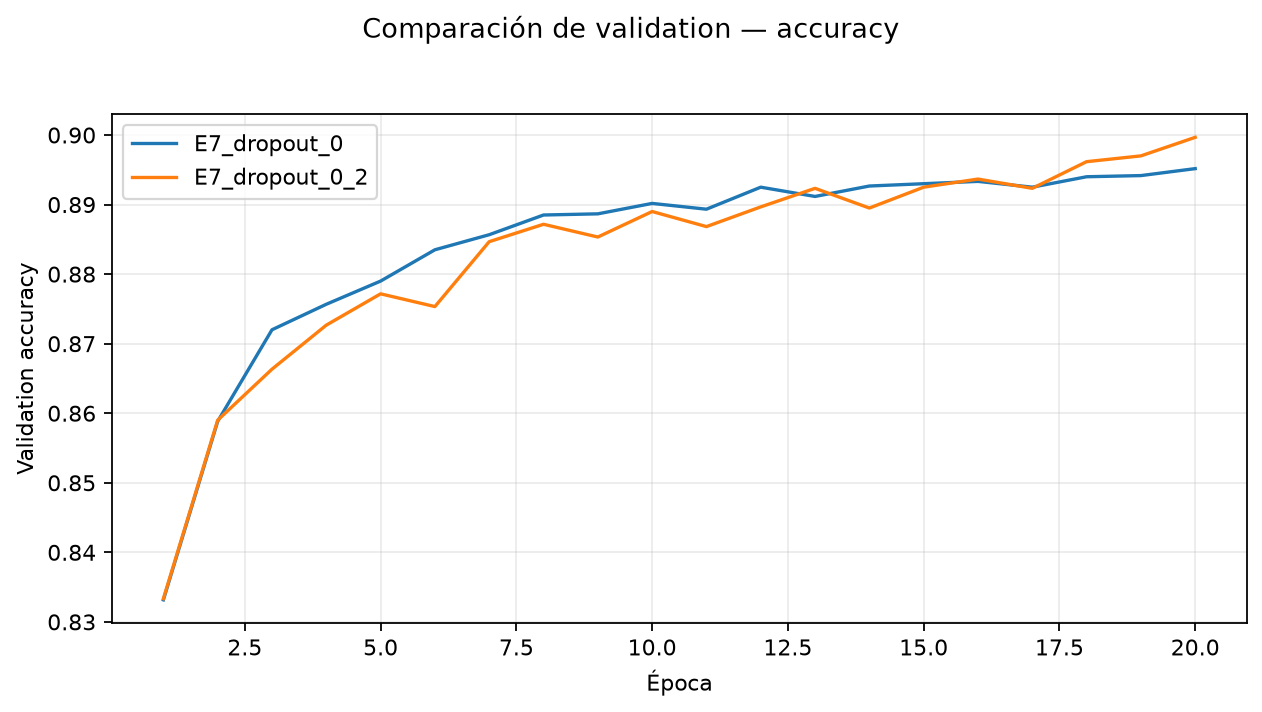

# E8 — comparación controlada de Batch Normalization

Se parte del control seleccionado en E7: MLP `[256, 128]`, ReLU, Softmax, categorical crossentropy, SGD con `learning_rate=0,1`, batch 128, 20 épocas, seed 42, Dropout `0,2` y L2 `0`. La única variable modificada es Batch Normalization. Cuando está activa, cada bloque oculto usa el orden `Dense lineal → BatchNormalization → ReLU → Dropout`. El conjunto oficial de test no fue evaluado ni se generaron predicciones sobre él.

| ID | Batch Normalization | Parámetros | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss | Duración CPU |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| E8_batch_norm_off | OFF | **235.146** | **0,8997** | **0,8997** | **0,8997 (20)** | **0,2830 (20)** | **0,0021** | **0,0135** | **32,79 s** |
| E8_batch_norm_on | ON | 236.682 | 0,8922 | 0,8911 | 0,8922 (19) | 0,3062 (19) | 0,0294 | 0,0827 | 44,20 s |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. Las duraciones corresponden a una corrida CPU local y no son comparables con GPU o Colab.

## Decisión

Se mantiene Batch Normalization desactivada para E9. Activarla redujo 0,75 puntos porcentuales de accuracy y 0,86 puntos de F1 Macro, incrementó ambos gaps y añadió 1.536 parámetros y aproximadamente 11,41 segundos a la corrida de referencia.

El resultado no sostiene que Batch Normalization sea inútil en general: solo indica que, con esta arquitectura, Dropout `0,2`, learning rate `0,1` y 20 épocas, no mejoró el control. E9 evaluará L2 de forma separada manteniendo Batch Normalization apagada.

## Evidencia

- `configs/E8_batch_norm_off.json`
- `configs/E8_batch_norm_on.json`
- `results/figures/E8_batch_norm_validation_accuracy.png`
- `results/figures/E8_batch_norm_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E8_batch_norm_*`.


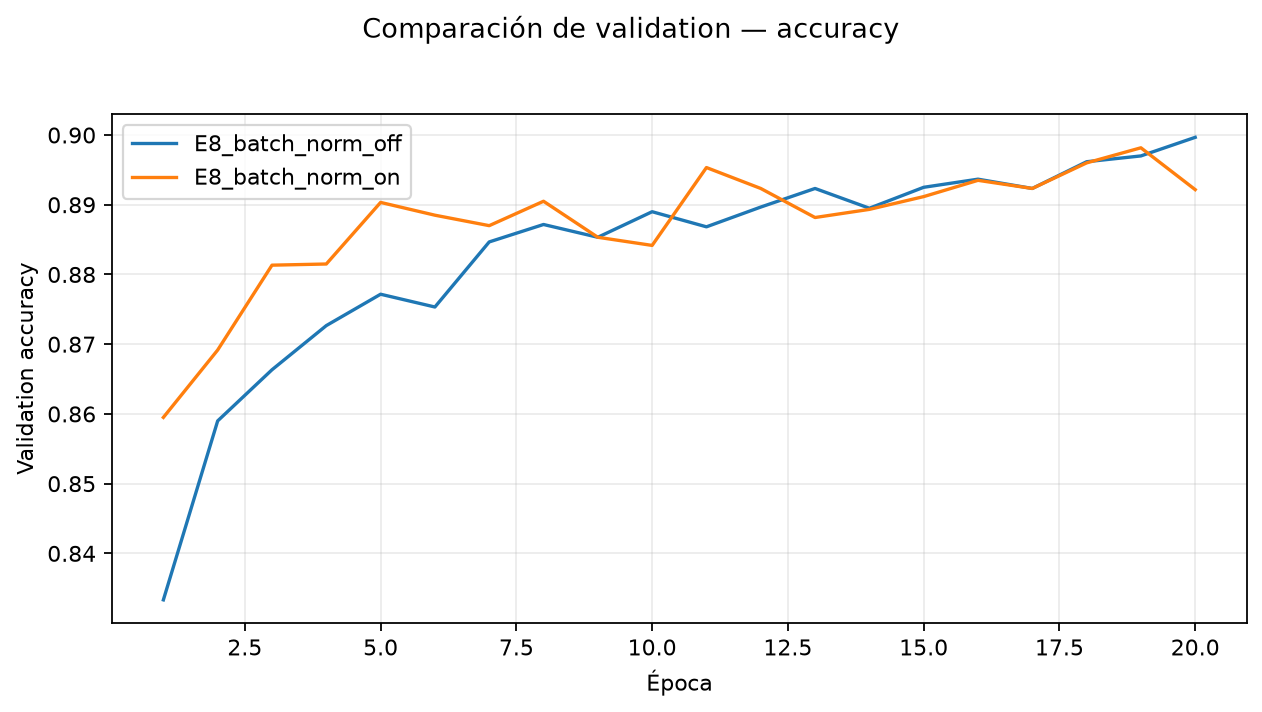

# E9 — comparación controlada de regularización L2

Se parte del control de E8: MLP `[256, 128]`, ReLU, Softmax, categorical crossentropy, SGD con `learning_rate=0,1`, batch 128, 20 épocas, seed 42, Dropout `0,2` y Batch Normalization apagada. La única variable modificada es la fuerza L2. El conjunto oficial de test no fue evaluado ni se generaron predicciones sobre él.

| ID | L2 | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss |
|---|---:|---:|---:|---:|---:|---:|---:|
| E9_l2_0 | **0** | **0,8997** | **0,8997** | **0,8997 (20)** | **0,2804 (20)** | **0,0021** | 0,0135 |
| E9_l2_1e-4 | 0,0001 | 0,8967 | 0,8970 | 0,8985 (19) | 0,3369 (19) | 0,0025 | **0,0102** |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. La loss de la fila con L2 incluye la penalización regularizadora; por tanto, no es directamente equivalente a la loss sin L2 como estimación de ajuste puro.

## Decisión

Se mantiene L2 en cero. La variante `1e-4` no superó la Accuracy ni F1 Macro del control y su mejor accuracy (`0,8985`) permaneció por debajo de la accuracy final sin L2 (`0,8997`). Aunque su gap de loss final fue ligeramente menor, el control ya presenta gaps de generalización muy bajos gracias a Dropout `0,2`, por lo que no se justifica introducir complejidad adicional.

Esta decisión es contextual: no afirma que L2 sea inefectiva en general. No se evaluaron combinaciones de L2 con Batch Normalization porque E8 ya mostró que esa técnica no mejoró el control. El modelo no queda congelado ni se consulta test.

## Evidencia

- `configs/E9_l2_0.json`
- `configs/E9_l2_1e-4.json`
- `results/figures/E9_l2_validation_accuracy.png`
- `results/figures/E9_l2_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E9_l2_*`.


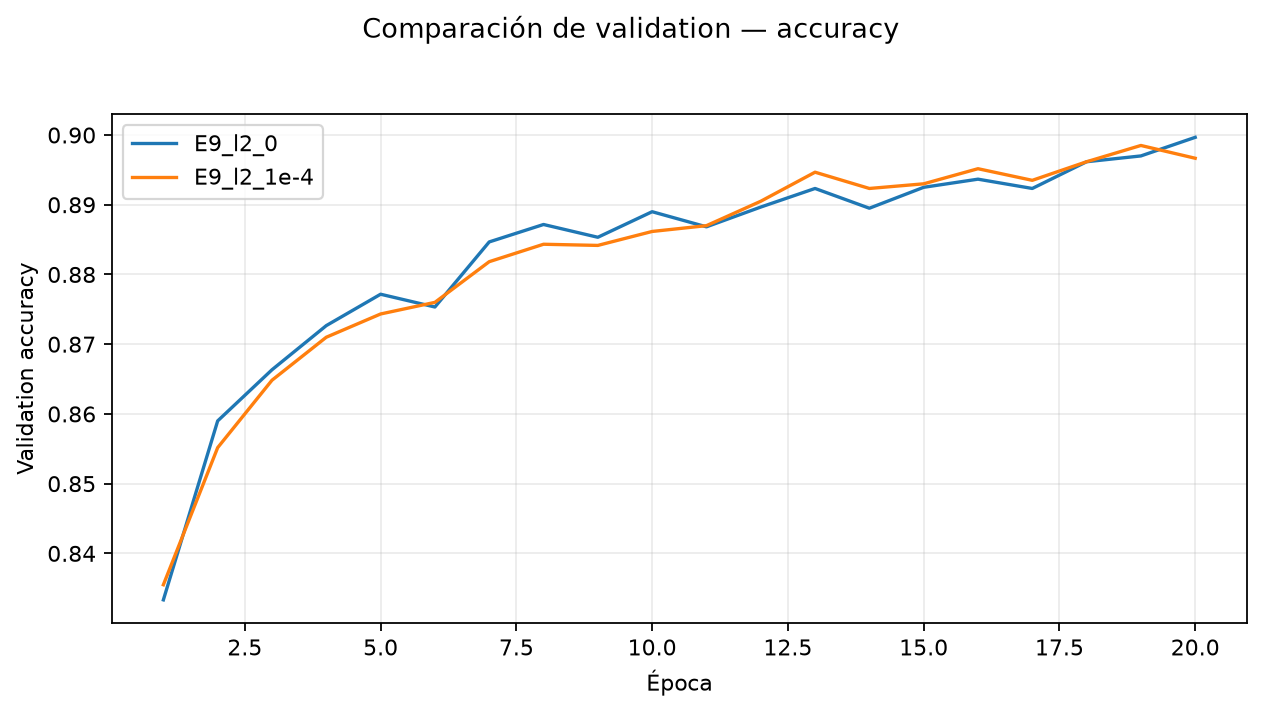

In [3]:
for table, figure in (
    ('E7_dropout_comparison.md', 'E7_dropout_validation_accuracy.png'),
    ('E8_batch_norm_comparison.md', 'E8_batch_norm_validation_accuracy.png'),
    ('E9_l2_comparison.md', 'E9_l2_validation_accuracy.png'),
):
    show_table(table)
    show_figure(figure)

## F0 — congelamiento antes de test

La configuración se seleccionó con validation, gaps y una repetición adicional de la decisión L2. Early Stopping no se implementó porque las curvas siguieron mejorando hasta la época 20; no existía una oportunidad material que justificara introducir un callback sin comparación controlada.

In [4]:
show_table('F0_frozen_protocol.md')
show_table('FINAL_MODEL_SELECTION.md')

# F0 — configuración y protocolo congelados antes de test

**Estado:** congelado antes de test. El conjunto oficial de test permanece sin evaluación ni predicción.

## Configuración seleccionada

| Componente | Valor congelado |
|---|---|
| Arquitectura | `[256, 128]` |
| Activación oculta / salida | ReLU / Softmax de 10 unidades |
| Loss / etiquetas | categorical crossentropy / one-hot |
| Optimizador / learning rate | SGD / `0,1` |
| Batch / épocas | 128 / 20 |
| Dropout | `0,2` tras cada capa oculta |
| Batch Normalization | desactivada |
| L2 | `0` |
| Early Stopping | desactivado |
| Seed | 42 |

## Criterio y protocolo de selección

La candidata se seleccionó por Accuracy, F1 Macro, curvas de validation, gaps, complejidad y evidencia de E6-E9. E7 eligió Dropout `0,2`; E8 y E9 descartaron Batch Normalization y L2 en las condiciones evaluadas. La repetición con seed 7 confirmó que L2 `1e-4` quedó por debajo del control sin L2 en ambas seeds disponibles.

Se adopta la estrategia **evaluar el modelo seleccionado que conserva el split 54.000/6.000**. No se reentrenará con los 60.000 ejemplos oficiales: el modelo final se entrenará una vez con la configuración congelada y se evaluará sobre los 10.000 ejemplos de test exactamente una vez. Las 20 épocas se fijan antes de test porque la mejor validation loss/accuracy del control aparece al final del presupuesto y no existe evidencia material para Early Stopping.

## Presupuesto de test

1. Entrenar una única vez el modelo congelado con train 54.000 y validation 6.000.
2. Evaluar y predecir sobre test oficial una sola vez.
3. Calcular métricas globales y por clase, matriz de confusión y ejemplos de errores.
4. No realizar ningún ajuste posterior desde test.

La configuración exacta está en `configs/F0_frozen_config.json`.


# Selección final consolidada

## Configuración congelada antes de test

La selección se realizó exclusivamente con train/validation y quedó congelada en `configs/F0_frozen_config.json` antes de consultar el conjunto oficial de test.

| Componente | Selección | Evidencia de validation |
|---|---|---|
| Arquitectura | MLP `[256, 128]` | Equilibrio entre desempeño, parámetros y gaps en E5. |
| Activación / salida / pérdida | ReLU / Softmax / categorical crossentropy | E1/E2; combinación de control para clasificación multiclase. |
| Optimizador | SGD, learning rate `0,1` | E6b: Accuracy `0,8952`, F1 Macro `0,8954`; mejor compromiso frente a Adam y RMSProp retuneados. |
| Batch size / épocas | `128` / `20` | E4 y curvas E7/E9: la mejor validation accuracy y loss quedan al final de las 20 épocas. |
| Dropout | `0,2` | E7: Accuracy `0,8997`, F1 Macro `0,8997` y gaps menores que sin Dropout. |
| Batch Normalization | desactivada | E8: activarla redujo Accuracy y F1 Macro, y aumentó gaps. |
| L2 | `0` | E9 y repetición seed 7: `1e-4` no mejoró Accuracy ni F1 Macro. |
| Early Stopping | desactivado | No había deterioro ni ahorro material; no se implementó sin una comparación interpretable. |

Las dos repeticiones de la decisión L2 conservaron la dirección de la selección: sin L2 obtuvo Accuracy de validation `0,8997` y `0,8902` (promedio `0,8949`); con L2 `1e-4`, `0,8967` y `0,8863` (promedio `0,8915`).

## Evaluación final única

Después de F0, el modelo seleccionado se entrenó con el split 54.000/6.000 y se evaluó una única vez sobre los 10.000 ejemplos oficiales de test. No se ajustó ningún parámetro después de este resultado.

| Métrica | Test |
|---|---:|
| Accuracy | 0,8838 |
| Precision macro | 0,8844 |
| Recall macro | 0,8838 |
| F1 macro | 0,8836 |
| Precision ponderada | 0,8844 |
| Recall ponderado | 0,8838 |
| F1 ponderado | 0,8836 |

La matriz de confusión muestra dificultades principalmente entre clases de prendas superiores visualmente similares. `Shirt` es la clase con menor F1 (`0,6975`); por ello, este resultado se comunica como limitación del modelo y no se utiliza para hacer nuevos ajustes.

## Trazabilidad

- Decisiones D-014--D-026: `docs/DECISION_LOG.md`.
- Comparaciones: `results/tables/E1_E2_validation_comparison.md`, `E3_learning_rate_comparison.md`, `E4_batch_size_comparison.md`, `E5_capacity_comparison.md`, `E6b_retuned_optimizer_comparison.md`, `E7_dropout_comparison.md`, `E8_batch_norm_comparison.md` y `E9_l2_comparison.md`.
- Protocolo: `results/tables/F0_frozen_protocol.md`.
- Evaluación definitiva: `results/tables/F1_final_test_summary.md` y las figuras `F1_test_*`.


## F1 — evaluación final única

El modelo congelado se evaluó una vez sobre los 10.000 ejemplos oficiales de test: Accuracy `0,8838` y F1 Macro `0,8836`. Shirt fue la clase más difícil (F1 `0,6975`) y las confusiones se concentran en prendas superiores visualmente parecidas. Estos resultados no habilitan nuevos ajustes.

# F1 — evaluación final única sobre test

La configuración `F0_frozen_config` se entrenó con train 54.000/validation 6.000 y se evaluó una única vez sobre los 10.000 ejemplos oficiales de test. Después de esta consulta no se realizaron ajustes.

| Métrica | Test |
|---|---:|
| Accuracy | 0,8838 |
| Precision macro | 0,8844 |
| Recall macro | 0,8838 |
| F1 macro | 0,8836 |
| Precision ponderada | 0,8844 |
| Recall ponderado | 0,8838 |
| F1 ponderado | 0,8836 |

## Métricas por clase

| Clase | Precision | Recall | F1 |
|---|---:|---:|---:|
| T-shirt/top | 0,8721 | 0,7980 | 0,8334 |
| Trouser | 0,9898 | 0,9700 | 0,9798 |
| Pullover | 0,7958 | 0,7990 | 0,7974 |
| Dress | 0,8394 | 0,9250 | 0,8801 |
| Coat | 0,8030 | 0,8070 | 0,8050 |
| Sandal | 0,9795 | 0,9550 | 0,9671 |
| Shirt | 0,7021 | 0,6930 | 0,6975 |
| Sneaker | 0,9238 | 0,9700 | 0,9463 |
| Bag | 0,9710 | 0,9720 | 0,9715 |
| Ankle boot | 0,9674 | 0,9490 | 0,9581 |

La principal dificultad es `Shirt`, seguida por las confusiones visualmente plausibles entre T-shirt/top y Shirt, Pullover y Coat. La matriz de confusión lo respalda; no se ajusta el modelo después de observarlo.

## Evidencia

- `results/figures/F1_test_confusion_matrix.png`
- `results/figures/F1_test_low_confidence_errors.png`
- Registro local protegido: `results/runs/F1_final_test/F1_final_test_record.json`.


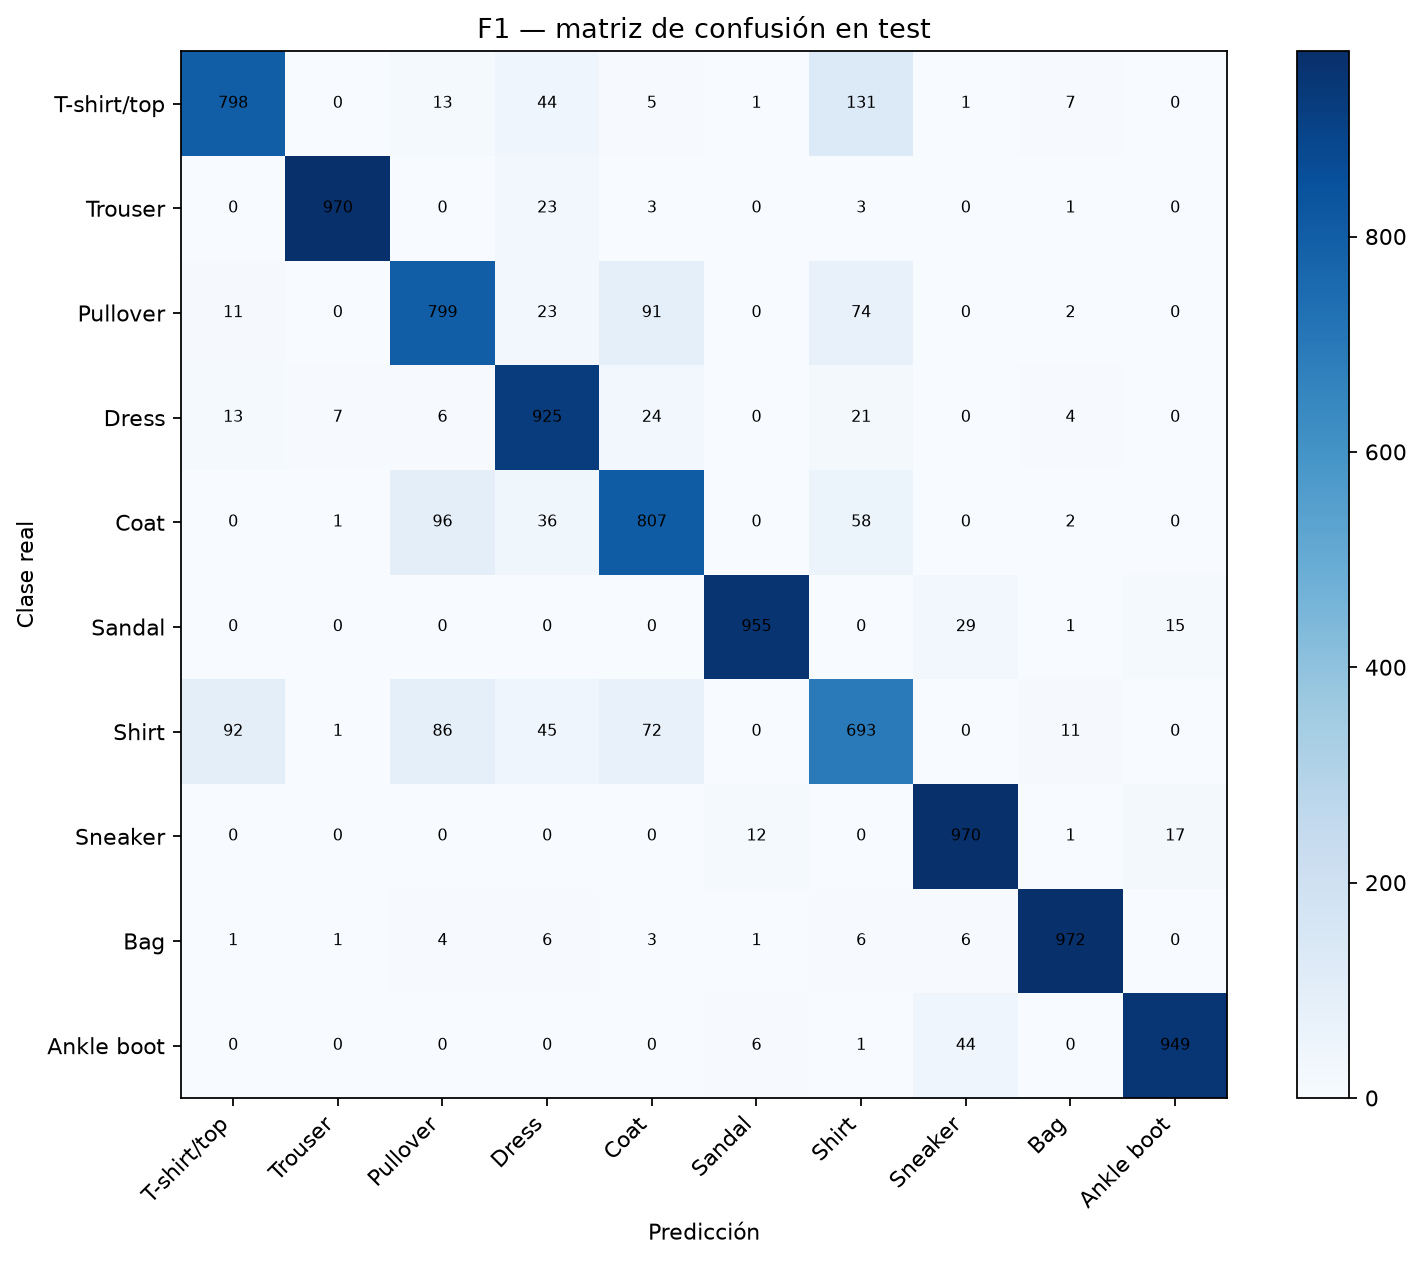

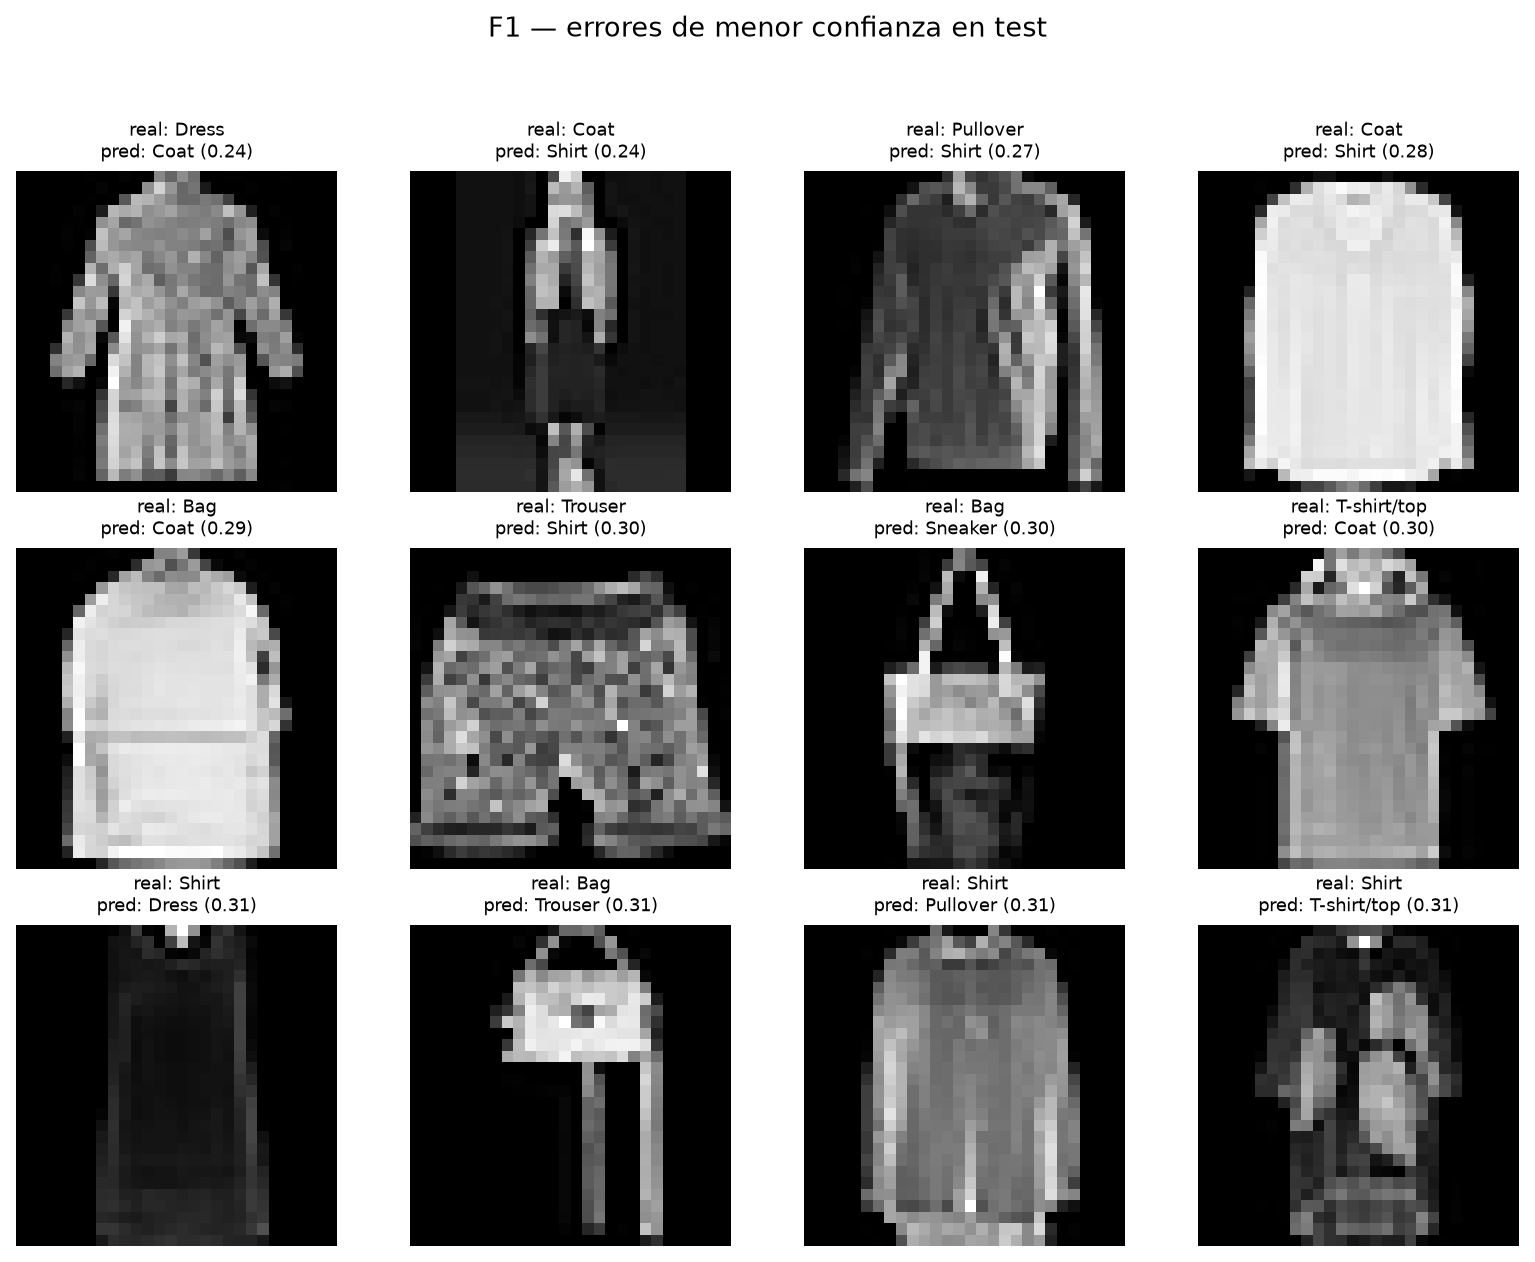

In [5]:
show_table('F1_final_test_summary.md')
show_figure('F1_test_confusion_matrix.png', width=900)
show_figure('F1_test_low_confidence_errors.png', width=900)

## Conclusión para la defensa

La selección no se apoyó en una única métrica: se compararon Accuracy, F1 Macro, curvas de validation, gaps, complejidad y repeticiones cuando la diferencia era marginal. La principal mejora de esta etapa fue Dropout `0,2`; Batch Normalization y L2 no aportaron bajo el control seleccionado. La matriz de confusión permite comunicar de manera honesta la limitación principal del modelo: distinguir prendas superiores similares.